<a href="https://colab.research.google.com/github/AlifHammam/data-science-2026/blob/main/Pertemuan10_AlifHammamMultazam_240401010043.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pertemuan 10 - Algoritma Klasifikasi (Bagian 2): Prediksi Customer Churn dengan Random Forest

**Nama Lengkap:** Alif Hammam Multazam  
**NIM:** 240401010043  
**Kelas:** IF403

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, precision_score,
                             recall_score, f1_score)

print('Library berhasil diimport!')

Library berhasil diimport!


## 2. Muat dan Eksplorasi Data

In [2]:
# Dataset Telco Customer Churn (dataset publik)
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)

print('Shape:', df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Proporsi kelas target untuk memastikan dataset bersifat imbalanced
print(df['Churn'].value_counts(normalize=True).round(3))

Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


## 3. Preprocessing

In [4]:
# Kolom customerID tidak relevan untuk pemodelan
df = df.drop(columns=['customerID'])

# TotalCharges kadang berupa string kosong -> ubah ke numerik
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Encoding target
y = df['Churn'].map({'Yes': 1, 'No': 0})

# Encoding fitur kategorikal dengan one-hot encoding
X = pd.get_dummies(df.drop(columns=['Churn']), drop_first=True)

print('Shape fitur setelah encoding:', X.shape)

Shape fitur setelah encoding: (7043, 30)


In [5]:
# Train-Test Split, stratify agar proporsi kelas terjaga
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (5634, 30) | Test: (1409, 30)


## 4. Latih Model: Random Forest

In [6]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_features='sqrt',
    class_weight='balanced',   # menangani imbalanced dataset
    random_state=42
)
rf.fit(X_train, y_train)

print('Model Random Forest berhasil dilatih!')

Model Random Forest berhasil dilatih!


## 5. Evaluasi Model

In [7]:
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=['Tidak Churn', 'Churn']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}')

[[925 110]
 [187 187]]
              precision    recall  f1-score   support

 Tidak Churn       0.83      0.89      0.86      1035
       Churn       0.63      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC: 0.825


                             Fitur  Importance
3                     TotalCharges    0.177844
1                           tenure    0.164403
2                   MonthlyCharges    0.151054
25               Contract_Two year    0.059944
10     InternetService_Fiber optic    0.042323
28  PaymentMethod_Electronic check    0.036455
24               Contract_One year    0.029412
13              OnlineSecurity_Yes    0.028447
4                      gender_Male    0.025604
26            PaperlessBilling_Yes    0.024087


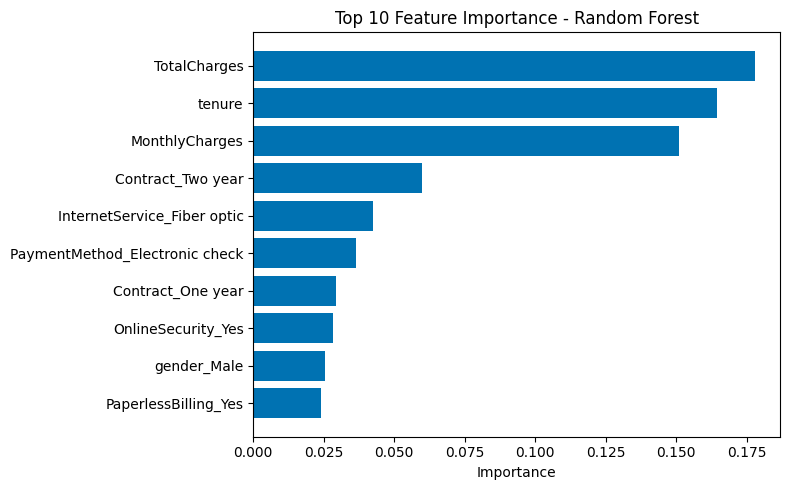

In [8]:
# Feature importance - fitur paling berpengaruh terhadap churn
importance = pd.DataFrame({
    'Fitur': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance.head(10))

plt.figure(figsize=(8, 5))
plt.barh(importance['Fitur'].head(10)[::-1], importance['Importance'].head(10)[::-1], color='#0072B2')
plt.xlabel('Importance')
plt.title('Top 10 Feature Importance - Random Forest')
plt.tight_layout()
plt.show()

## 6. Prediksi Probabilitas & Threshold Tuning

In [9]:
# Bandingkan threshold default (0.5) dengan threshold lebih rendah (0.35)
pred_default = (y_proba >= 0.5).astype(int)
pred_rendah  = (y_proba >= 0.35).astype(int)

for label, pred in [('Threshold 0.50', pred_default), ('Threshold 0.35', pred_rendah)]:
    print(f"\n{label}")
    print(f"Precision: {precision_score(y_test, pred):.3f}")
    print(f"Recall   : {recall_score(y_test, pred):.3f}")
    print(f"F1-Score : {f1_score(y_test, pred):.3f}")


Threshold 0.50
Precision: 0.627
Recall   : 0.503
F1-Score : 0.558

Threshold 0.35
Precision: 0.549
Recall   : 0.679
F1-Score : 0.607


### Kesimpulan Singkat Hasil Model

1. Dataset Telco Customer Churn bersifat imbalanced, dengan pelanggan yang tidak churn jauh lebih banyak dibanding yang churn.
2. Penggunaan `class_weight='balanced'` pada Random Forest membantu model lebih peka terhadap kelas minoritas (churn) dibanding model tanpa penanganan imbalance.
3. Fitur seperti tenure, Contract, dan MonthlyCharges cenderung menjadi pendorong utama prediksi churn berdasarkan feature importance.
4. Menurunkan threshold keputusan dari 0.5 ke 0.35 meningkatkan Recall (lebih banyak pelanggan berisiko tertangkap) namun menurunkan Precision, sesuai trade-off yang diharapkan.

## Kesimpulan

Pada praktikum pertemuan kesepuluh ini saya mempelajari konsep ensemble learning, khususnya algoritma Random Forest yang menggabungkan banyak Decision Tree melalui bootstrap sampling dan random feature selection. Saya juga mempelajari permasalahan imbalanced dataset yang umum terjadi pada kasus customer churn, serta cara menanganinya melalui class_weight dan threshold tuning.

Melalui dataset Telco Customer Churn, saya memahami bahwa Accuracy saja tidak cukup untuk mengevaluasi model pada data yang tidak seimbang (accuracy paradox), sehingga metrik seperti Precision, Recall, F1-Score, dan ROC-AUC menjadi lebih relevan, terutama Recall yang menjadi prioritas agar pelanggan berisiko churn tidak terlewat.

Keterbatasan pada praktikum ini adalah belum dilakukan perbandingan lengkap dengan teknik resampling seperti SMOTE, serta belum dilakukan hyperparameter tuning menyeluruh pada Random Forest. Namun, praktikum ini memberikan pemahaman yang baik mengenai ensemble learning dan strategi penanganan data tak seimbang dalam kasus bisnis nyata.